In [1]:
from CTMC_Model import *
import numpy as np
import sqlite3
import bisect
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Start and end times to consider data between
start_time = '2026-04-26 00:00'
start_time_pd = pd.Timestamp(start_time)
end_time = '2026-05-31 23:59'

# %% Loading data to pandas dataframes for training
conn = sqlite3.connect('airport_data.db', isolation_level=None)

#Checking all airport codes are in airports table, and all airports have at least some flights
codes = conn.execute('SELECT DISTINCT airport FROM flights INTERSECT SELECT DISTINCT code FROM airports').fetchall()
codes = [c[0] for c in codes]
n_airports = len(codes)

#Removing any duplicate flight rows
conn.execute('''DELETE FROM flights
WHERE EXISTS (
  SELECT 1 FROM flights f2 
  WHERE flights.flight_code = f2.flight_code
  AND flights.flight_datetime = f2.flight_datetime
  AND flights.rowid > f2.rowid
);''')

#Selecting data from each airport
dfs = {}
for c in codes:
    #In cts case, add random number of micro seconds up to one minute, reflecting our ignorance about exact time and to break any ties
    data_cts = conn.execute('SELECT flight_code, flight_datetime, increment FROM flights WHERE (airport=? AND flight_datetime >= ? AND flight_datetime <= ?) ORDER BY flight_datetime',[c,start_time,end_time]).fetchall()
    df_cts = pd.DataFrame(data_cts,columns=('Flight Code', 'Datetime', 'Increment'))
    df_cts['Datetime'] = pd.to_datetime(df_cts['Datetime']).apply(lambda x: x + pd.Timedelta(random.randint(0,59999999),unit='us'))
    df_cts.sort_values('Datetime', inplace=True)
    df_cts['Number of Planes'] = df_cts['Increment'].cumsum()
    dfs[c] = df_cts
    

# %% Processing data frames for Markov chain model
for df in dfs.values():
    #Convert datetime into minutes from start
    df['Minutes From Start'] = (df['Datetime'] - start_time_pd).apply(lambda x: x.total_seconds()/60)
    #Adding initial state
    df.loc[len(df)] = [None,start_time_pd,0,df.iloc[0]['Number of Planes'] - df.iloc[0]['Increment'],0]
    df.sort_values('Minutes From Start',inplace=True)
    #df = pd.concat([df,pd.DataFrame({'Flight Code':None, 'Datetime': start_time_pd, 'Increment':0, 'Number of Planes':df.iloc[0]['Number of Planes'] - df.iloc[0]['Increment'], 'Minutes From Start': 0},index=[-1])])#
    #Subtracting min number of planes to get a state in {0,1,...,S-1}
    df['State'] = df['Number of Planes'] - min(df['Number of Planes'])

conn.close()

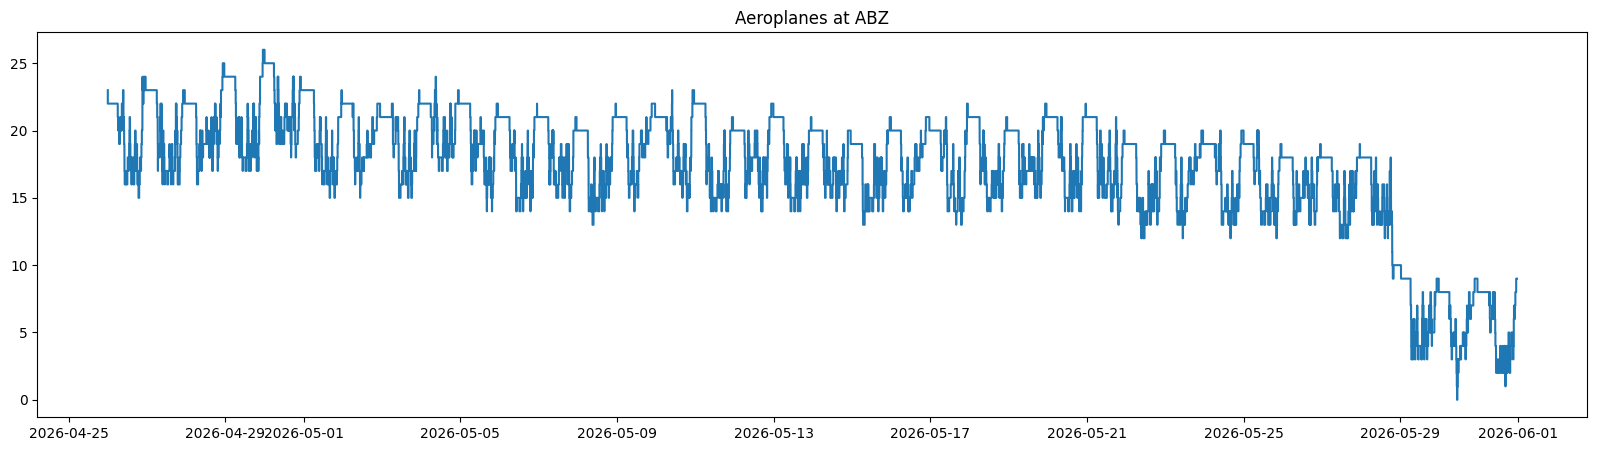

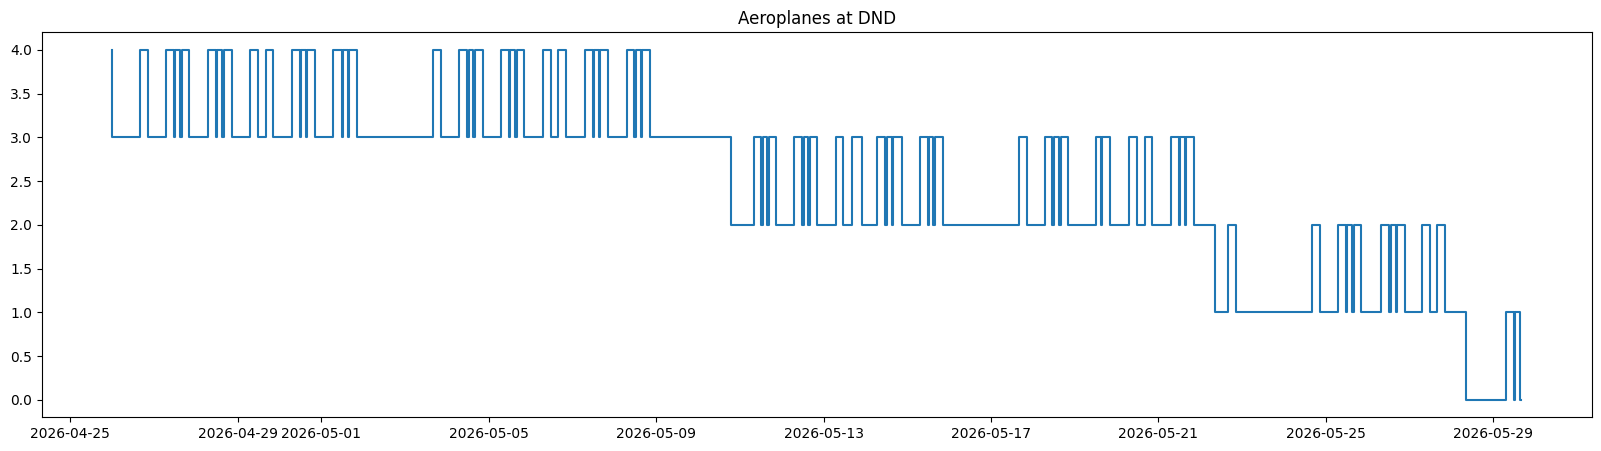

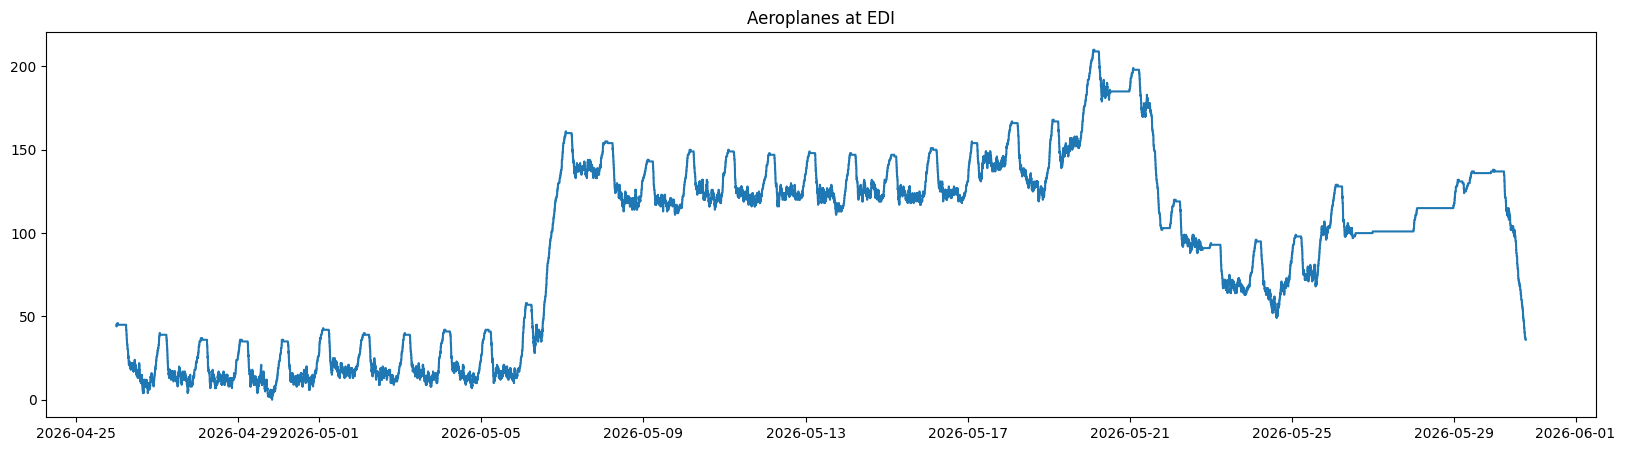

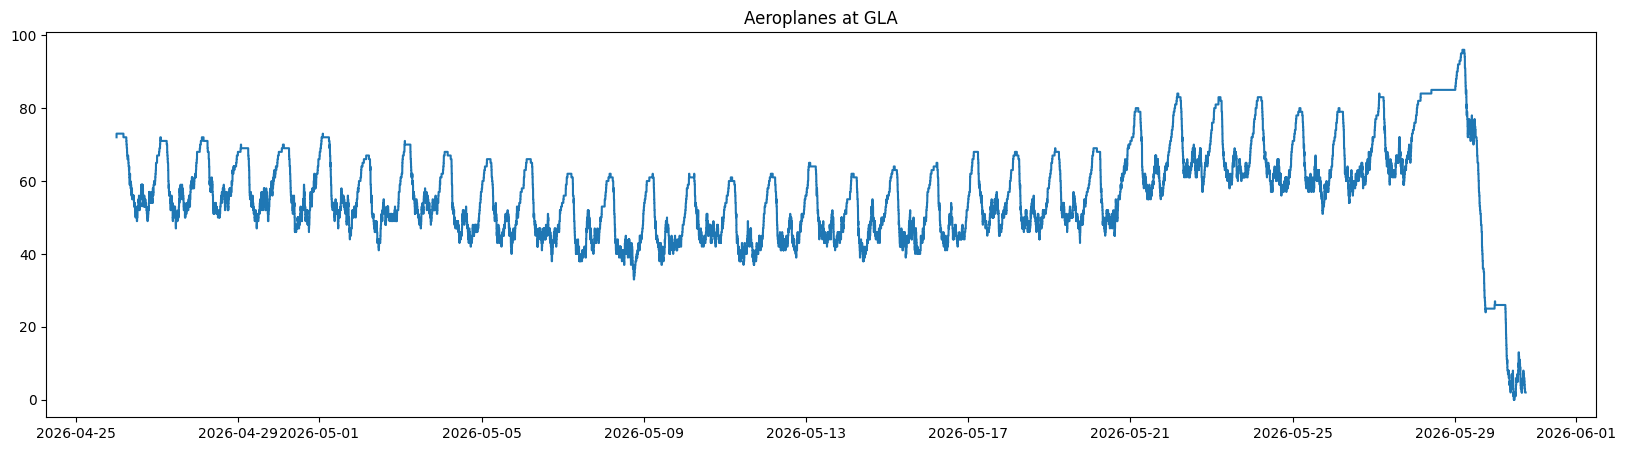

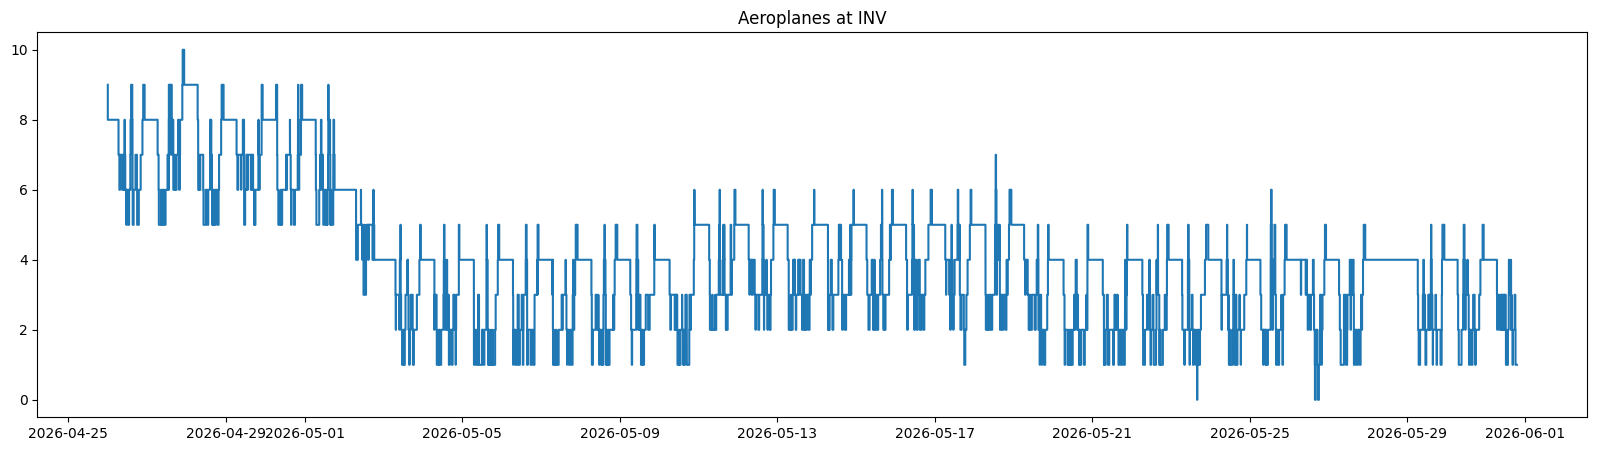

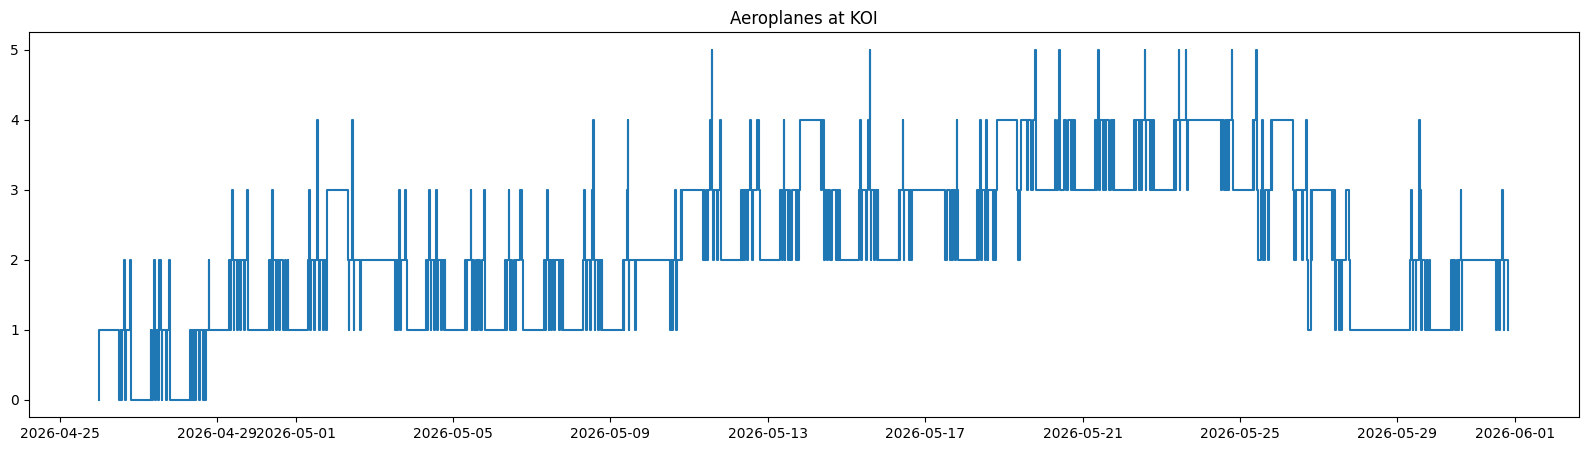

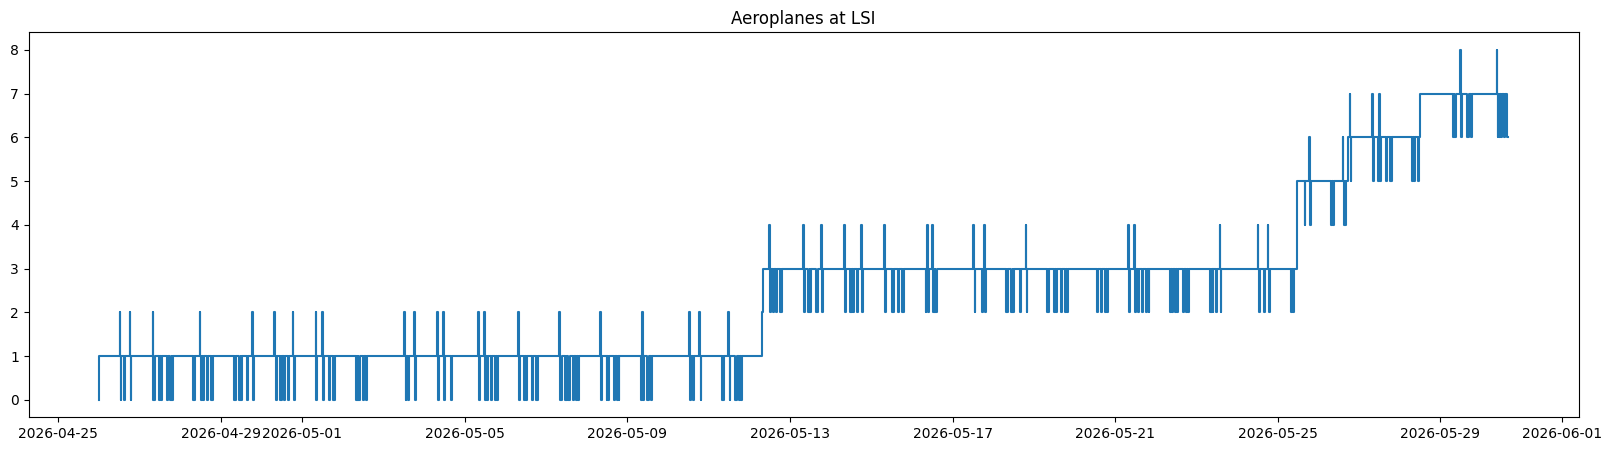

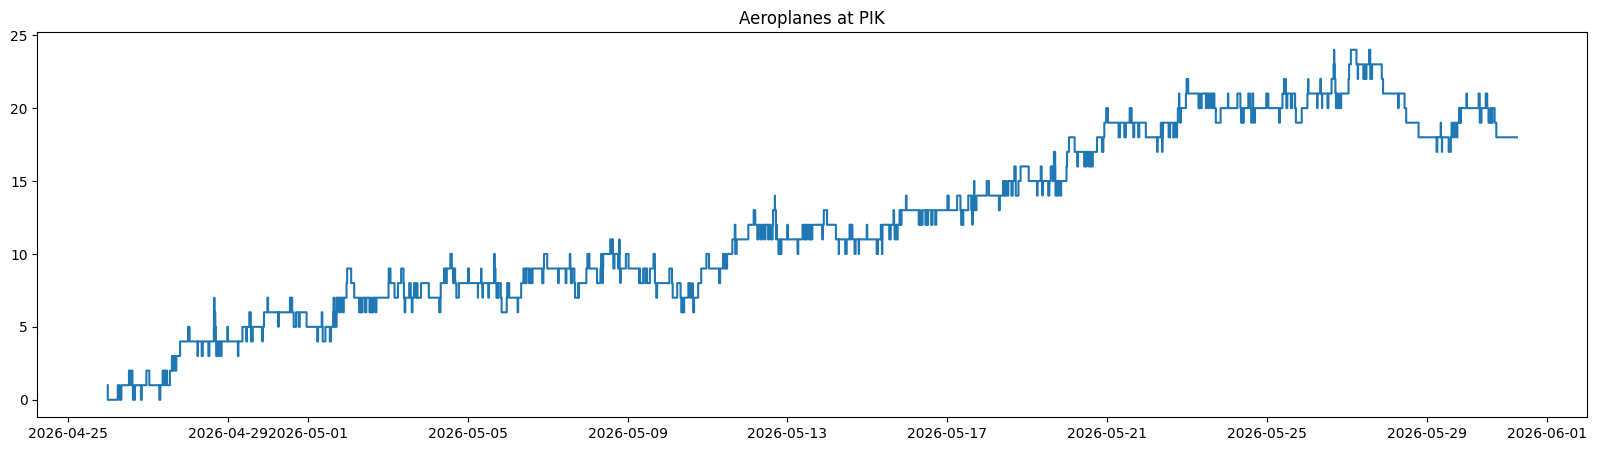

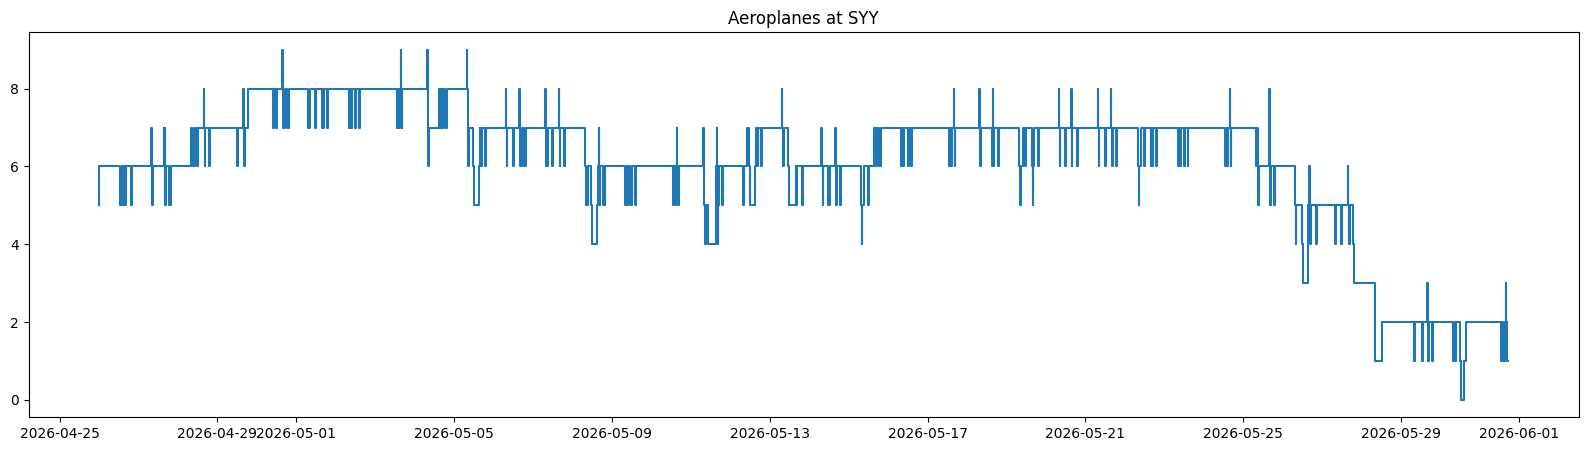

In [3]:
#Plotting time series for each airport
for c, df in dfs.items():
    states = df['State'].values
    times = df['Datetime'].values
    fig, axs = plt.subplots(figsize=(20,5))
    axs.set_title(f'Aeroplanes at {c}')
    axs.step(times,states)

Above plots show the time series for each airport. 

Observations:
    - Towards the end there is some missing data leading to unusual behaviour. This will be cut off for the analysis.
    - Edinburgh (EDI) has some bits of missing data resulting in the large spikes. We can use the complete subsections for analysis
    - There is an unusual upward trend at Glasgow Prestwick (PIK). Not sure what causes this (cannot be actually occurring). Can see how the model handles larger trends, as it was designed only for seasonal effects.

In [4]:
#Cutting datasets to complete sections
#Aberdeen (ABZ) - end at EOD 28/05/26
dfs['ABZ'] = dfs['ABZ'].query('Datetime < "2026-05-28 00:00"')

#Dundee (DND) - end at EOD 28/05/26
dfs['DND'] = dfs['DND'].query('Datetime < "2026-05-28 00:00"')

#Edinburgh (EDI) - end at EOD 06/05/26
dfs['EDI'] = dfs['EDI'].query('Datetime < "2026-05-06 00:00"')

#Glasgow (GLA) - end at EOD 28/05/26
dfs['GLA'] = dfs['GLA'].query('Datetime < "2026-05-28 00:00"')

#Inverness (INV) - end at EOD 28/05/26
dfs['INV'] = dfs['INV'].query('Datetime < "2026-05-28 00:00"')

#Kirkwall (KOI) - end at EOD 28/05/26
dfs['KOI'] = dfs['KOI'].query('Datetime < "2026-05-28 00:00"')

#Sumburgh (LSI) - end at EOD 28/05/26
dfs['LSI'] = dfs['LSI'].query('Datetime < "2026-05-28 00:00"')

#Glasgow Prestwick (PIK) - end at EOD 28/05/26
dfs['PIK'] = dfs['PIK'].query('Datetime < "2026-05-28 00:00"')

#Stornoway (SYY) - end at EOD 28/05/26
dfs['SYY'] = dfs['SYY'].query('Datetime < "2026-05-28 00:00"')

#Recomputing state as minimal value may have changed
for df in dfs.values():
    df['State'] = df['Number of Planes'] - min(df['Number of Planes'])

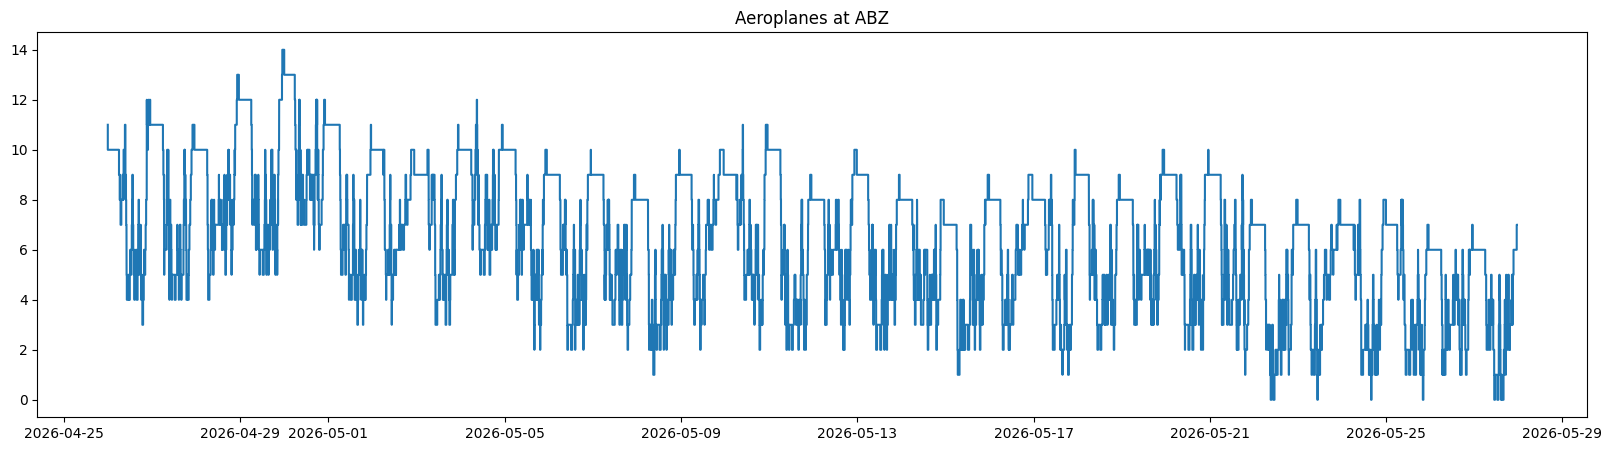

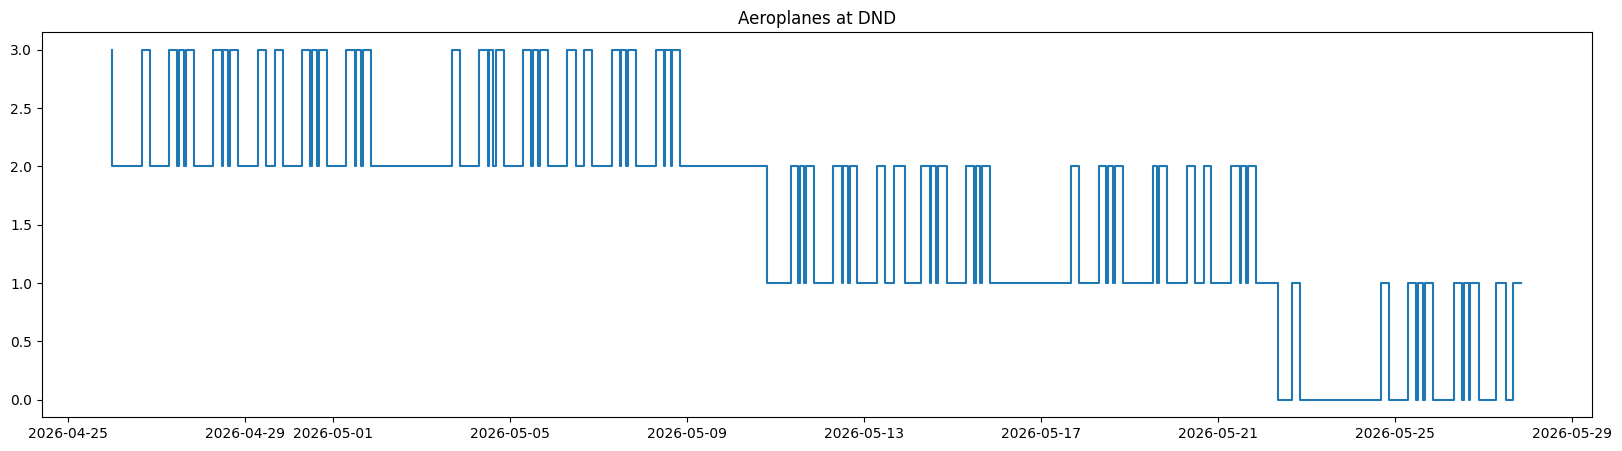

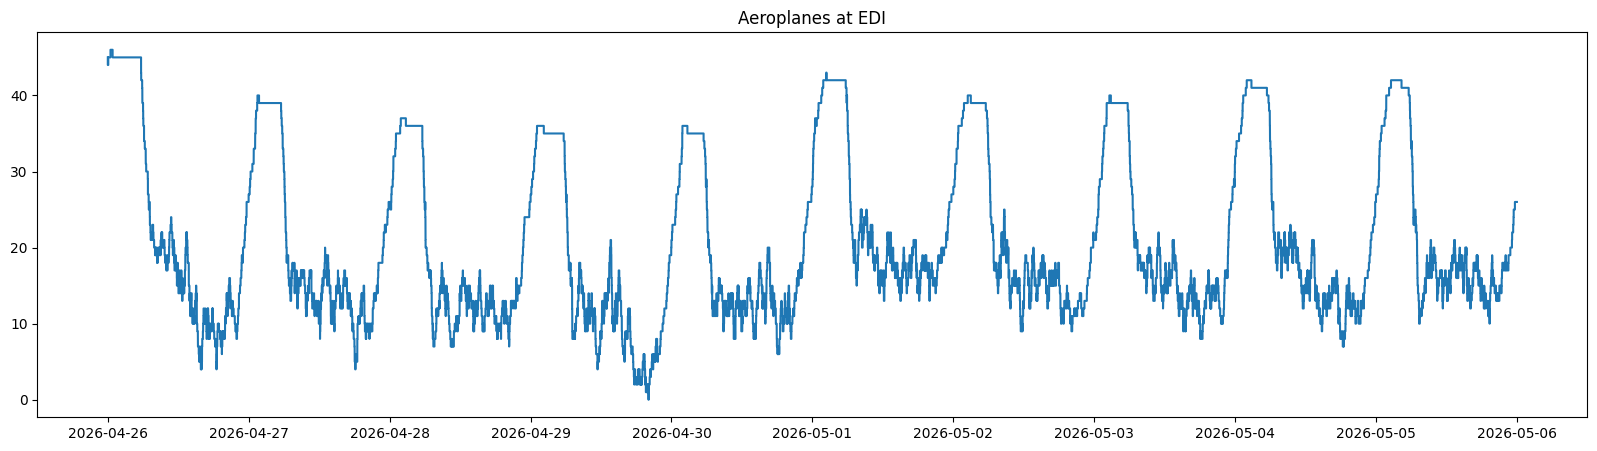

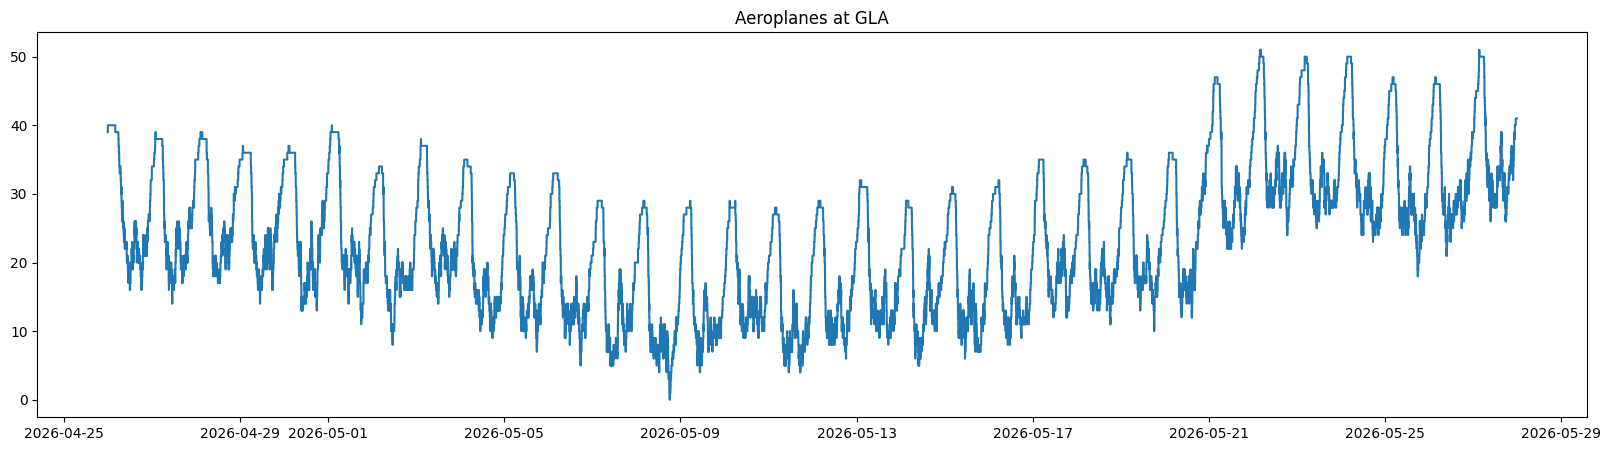

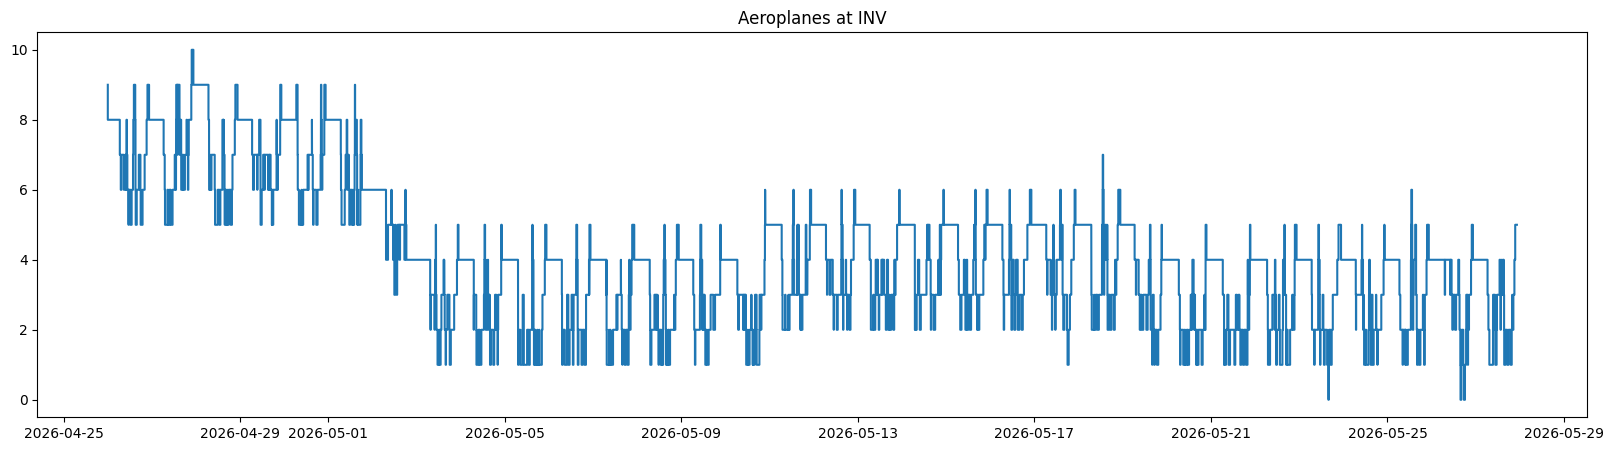

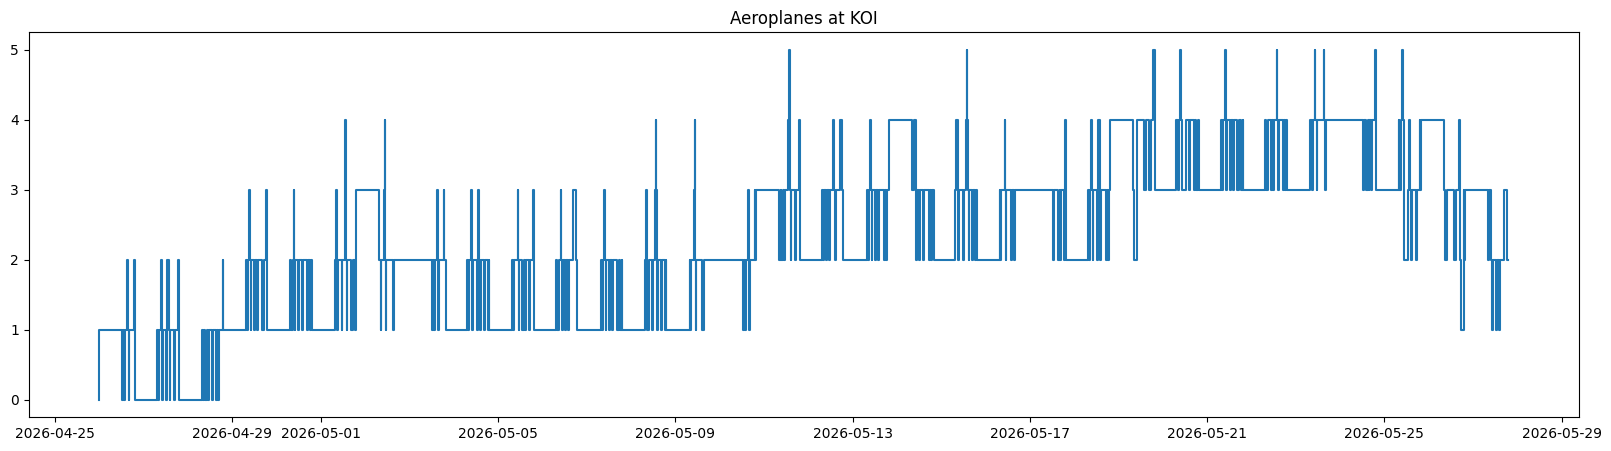

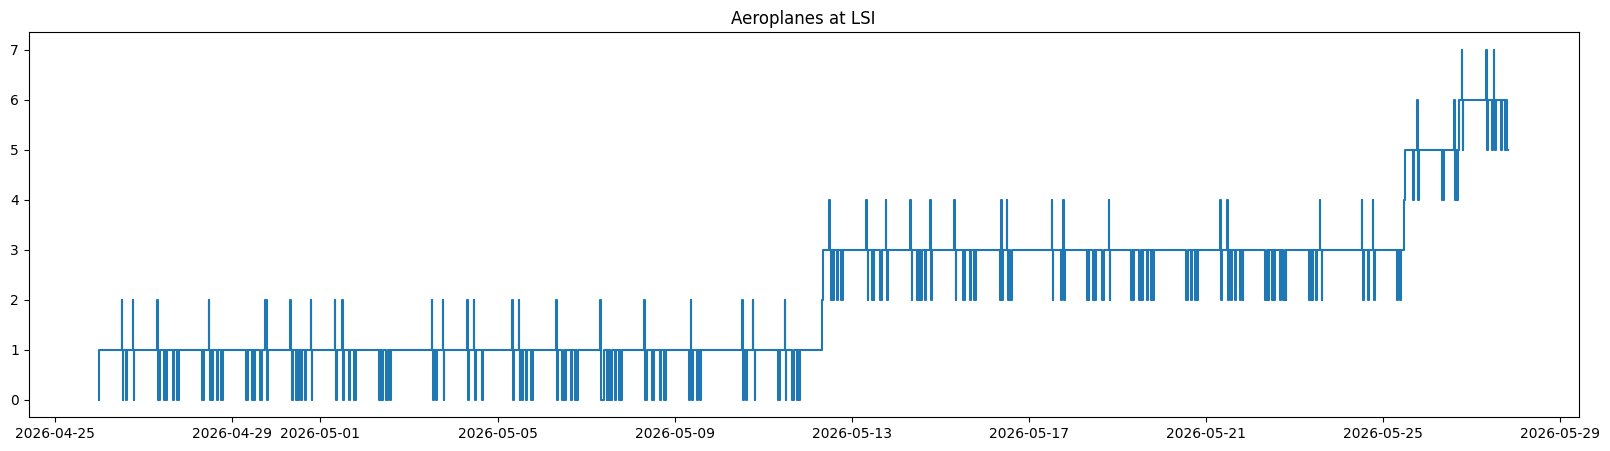

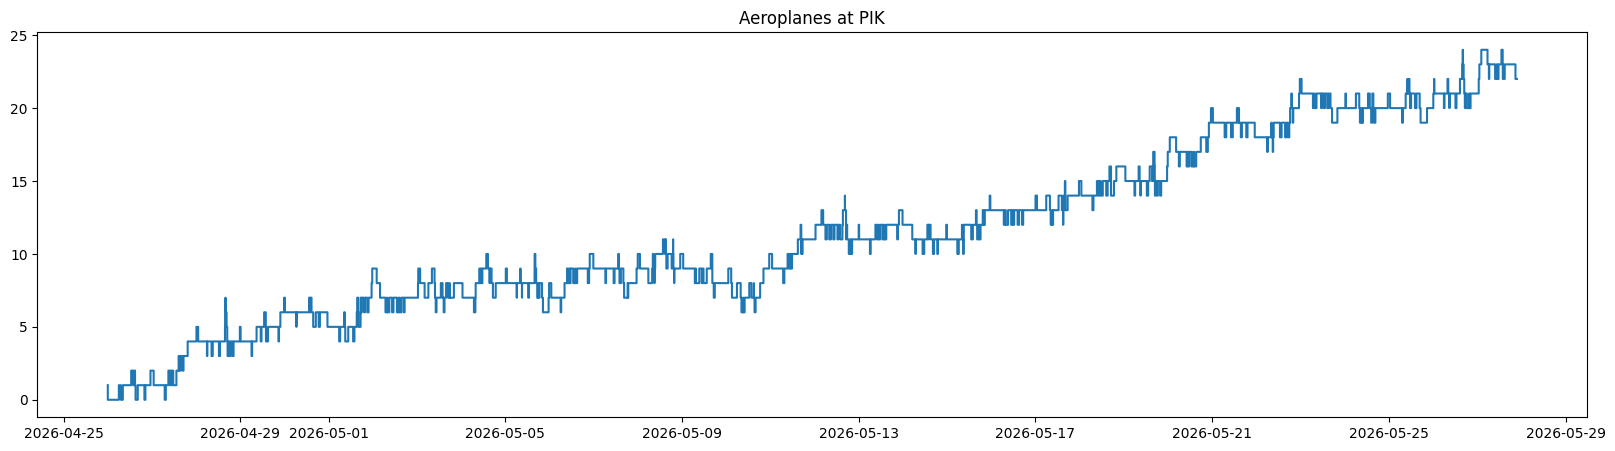

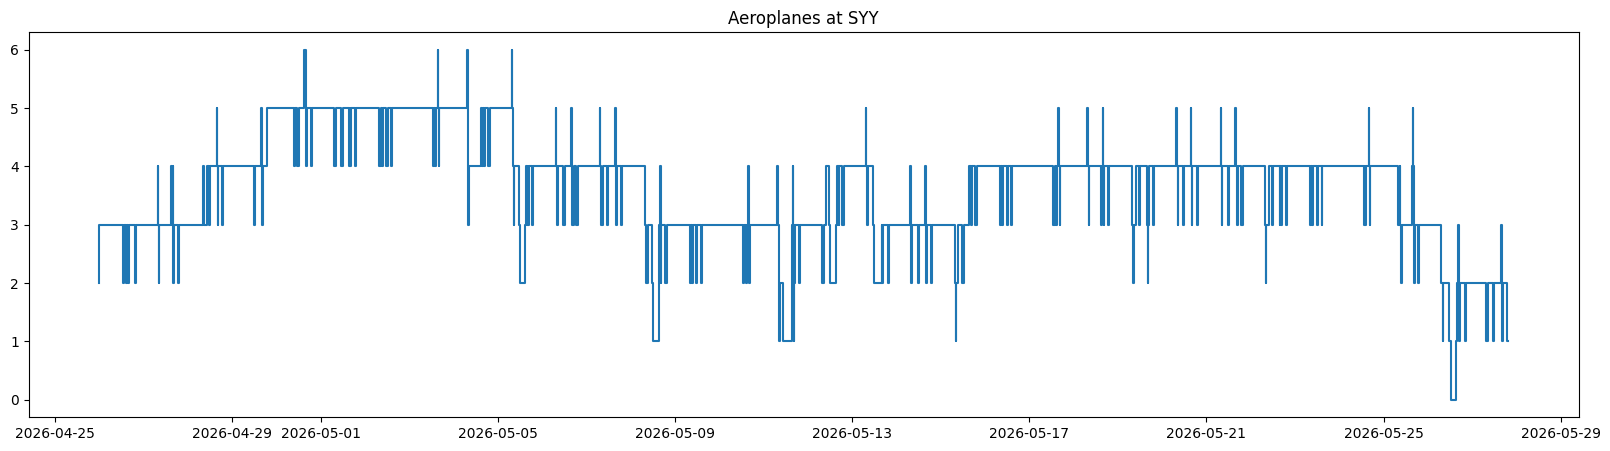

In [5]:
#Replotting time series for each airport
for c, df in dfs.items():
    states = df['State'].values
    times = df['Datetime'].values
    fig, axs = plt.subplots(figsize=(20,5))
    axs.set_title(f'Aeroplanes at {c}')
    axs.step(times,states)

Experiment 1: Comparing estimated error for lots of choices of partition times

The class CTMC computes an estimate for the L1 error of the model along with standard deviation estimates. Selecting Aberdeen (ABZ) as an example, I take a random selection of partition points, with 2, 3, 4 and 5 as number of partition points, and plot the errors and partition locations in a graph. This demonstrates the dependence of the model accuracy on the choice of partition points. For this experiment, I use the MLE method to fit model parameters.

Number of partitions - 2
1 - xi values: [251 908]
2 - xi values: [ 671 1327]


C:\Users\thecd\Documents\Code\Markov_Chain\CTMC_Model.py:153: RuntimeWarning: invalid value encountered in divide
  a = np.divide(num,den)


3 - xi values: [ 784 1046]
4 - xi values: [488 612]
5 - xi values: [ 205 1023]
6 - xi values: [ 656 1096]
7 - xi values: [ 28 231]
8 - xi values: [ 316 1254]
9 - xi values: [449 808]
10 - xi values: [248 391]
11 - xi values: [ 500 1405]
Jump time exceeds 4 days, set to inf
12 - xi values: [ 718 1075]
13 - xi values: [ 550 1402]
14 - xi values: [ 982 1060]
15 - xi values: [207 242]
16 - xi values: [ 67 204]
17 - xi values: [ 329 1202]
18 - xi values: [384 965]
19 - xi values: [ 863 1236]
20 - xi values: [ 340 1212]
21 - xi values: [  22 1034]
22 - xi values: [ 935 1398]
23 - xi values: [895 983]
24 - xi values: [ 225 1011]
25 - xi values: [121 722]
26 - xi values: [ 75 485]
27 - xi values: [ 809 1310]
28 - xi values: [ 270 1019]
29 - xi values: [738 766]
30 - xi values: [ 710 1402]
31 - xi values: [239 787]
32 - xi values: [126 680]
33 - xi values: [ 368 1392]
34 - xi values: [677 855]
35 - xi values: [ 84 199]
36 - xi values: [ 987 1420]
37 - xi values: [ 16 768]
38 - xi values: [ 249 

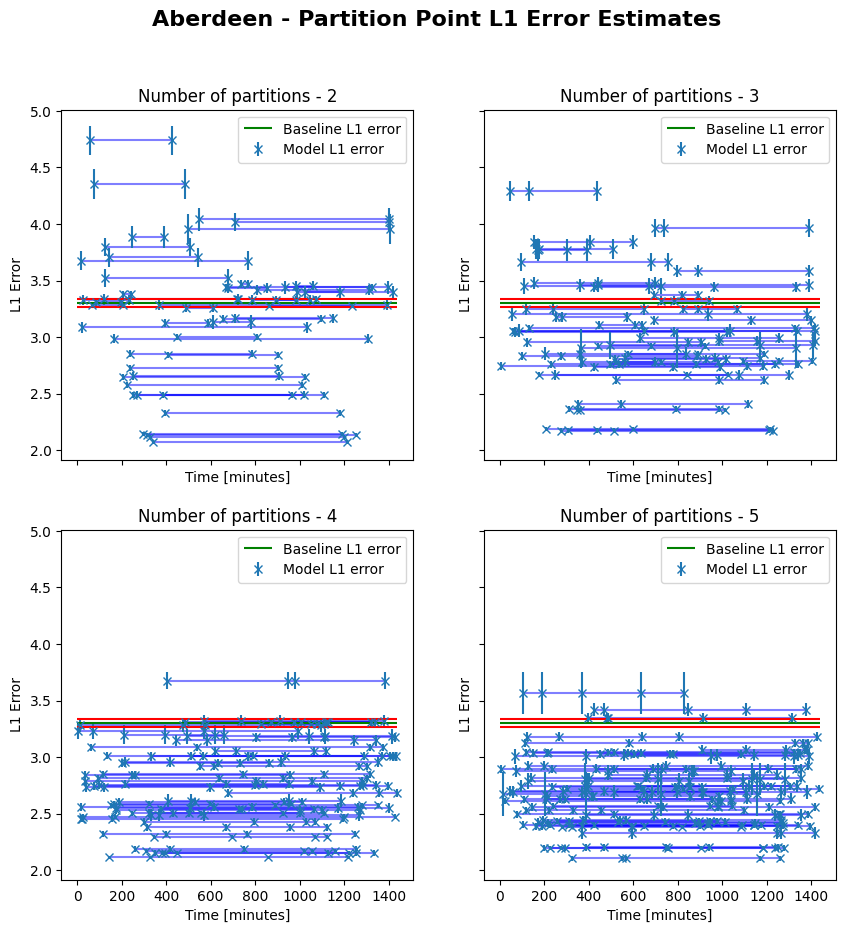

In [6]:
df = dfs['ABZ']
states = df['State'].values
times = df['Minutes From Start'].values
S = max(states) + 1
#Default model structure - all 1 off diagonals have own parameter, all others 0
structure = np.zeros((S,S))
for i in range(S-1):
     structure[i,i+1] = 2*i + 1
     structure[i+1,i] = 2*i + 2

#Number of paramter choices for each partition size
n_iter = 50

#Initialise figure
fig_1, axs_1 = plt.subplots(2,2,sharex=True,sharey=True,figsize=(10,10))
fig_1.suptitle('Aberdeen - Partition Point L1 Error Estimates',fontsize=16, fontweight='bold')

#Initialise CTMC object and compute baseline error coresponding to 1 partition point (i.e. time homogeneous model)
ctmc_1 = CTMC()
err_baseline = ctmc_1.fit(states,times,[0],a_optim='MLE',xi_optim='fixed')[0]

#Iterating over choice of number of partition points
for K in range(2,6):
    print(f'Number of partitions - {K}')
    ctmc_1 = CTMC()
    xi_list = []
    err_list = []
    log_l_list = []
    for i in range(n_iter):
        xi = np.sort(random.sample(list(range(0,1440)),k=K))
        print(f'{i+1} - xi values: {xi}')
        err, log_l = ctmc_1.fit(states,times,xi,a_optim='MLE',xi_optim='fixed',coeff_struct=structure)
        xi_list.append(xi)
        err_list.append(err)        
    #Plotting errors of each xi choice
    axs_1[K//4,K%2].set_title(f'Number of partitions - {K}')    
    x = np.array(xi_list)
    e = np.array(err_list)
    e_v = e[:,0]
    e_sd = e[:,1]
    axs_1[K//4,K%2].plot(x.T, np.vstack([e_v for i in range(K)]), color='blue', alpha=0.5)
    err_v_2 = np.ravel([[e[0] for i in range(K)] for e in err_list])
    err_sd_2 = np.ravel([[e[1] for i in range(K)] for e in err_list])
    axs_1[K//4,K%2].errorbar(np.ravel(x), err_v_2, yerr=err_sd_2, linestyle='None', marker='x', label='Model L1 error')
    axs_1[K//4,K%2].hlines(y=err_baseline[0],xmin=0,xmax=1440,color='green', label='Baseline L1 error')
    axs_1[K//4,K%2].hlines(y=[err_baseline[0] - err_baseline[1],err_baseline[0] + err_baseline[1]],xmin=0,xmax=1440,color='red')
    axs_1[K//4,K%2].legend()
    axs_1[K//4,K%2].set_xlabel('Time [minutes]')
    axs_1[K//4,K%2].set_ylabel('L1 Error')

Observations:

- All improve upon the time inhomogeneous model (as expected). The best performing choices for 4 and 5 partition points seem to have two or more very close together, suggesting perhaps 3 is a good choice, though of course this requires more analysis.

Experiment 2: Comparison of different parameter selection algorithms

Comparing the two methods of fitting the infinitesimal generator parameters (the 'a' parameters) and the two methods of fitting the partition points xi. I choose as an example Glasgow (GLA) and consider the case of three partition points

a_optim=MLE, xi_optim=anneal


C:\Users\thecd\Documents\Code\Markov_Chain\CTMC_Model.py:122: RuntimeWarning: divide by zero encountered in log
  term_1 = np.multiply(num,np.log(a1))


Iteration 1: log l: -16156.81246465231
Iteration 2: log l: -16159.869545905614
Iteration 3: log l: -16159.869545905614
Iteration 4: log l: -16071.372648695438
Iteration 5: log l: -16071.372648695438
Iteration 6: log l: -16071.372648695438
Iteration 7: log l: -16071.372648695438
Iteration 8: log l: -16071.372648695438
Iteration 9: log l: -16071.372648695438
Iteration 10: log l: -16071.372648695438
Iteration 11: log l: -16071.372648695438
Iteration 12: log l: -16071.372648695438
Iteration 13: log l: -15861.292455620252
Iteration 14: log l: -15861.292455620252
Iteration 15: log l: -15861.292455620252
Iteration 16: log l: -15861.292455620252
Iteration 17: log l: -15861.292455620252
Iteration 18: log l: -15861.292455620252
Iteration 19: log l: -15861.292455620252
Iteration 20: log l: -15861.292455620252
Iteration 21: log l: -15861.292455620252
Iteration 22: log l: -15861.292455620252
Iteration 23: log l: -15868.996624686228
Iteration 24: log l: -15868.996624686228
Iteration 25: log l: -1586

C:\Users\thecd\Documents\Code\Markov_Chain\CTMC_Model.py:193: RuntimeWarning: divide by zero encountered in divide
  a = np.divide(num,den)
C:\Users\thecd\Documents\Code\Markov_Chain\CTMC_Model.py:193: RuntimeWarning: invalid value encountered in divide
  a = np.divide(num,den)


Iteration 1: log l: -15797.141463100023
Iteration 2: log l: -15797.141463100023
Iteration 3: log l: -15869.512829964566
Iteration 4: log l: -15846.813763483211
Iteration 5: log l: -16542.69048510345
Iteration 6: log l: -16462.40409958855
Iteration 7: log l: -16462.40409958855
Iteration 8: log l: -16437.383890535675
Iteration 9: log l: -16437.383890535675
Iteration 10: log l: -16437.383890535675
Iteration 11: log l: -16437.383890535675
Iteration 12: log l: -16437.383890535675
Iteration 13: log l: -16437.383890535675
Iteration 14: log l: -16437.383890535675
Iteration 15: log l: -16437.383890535675
Iteration 16: log l: -16437.383890535675
Iteration 17: log l: -16437.383890535675
Iteration 18: log l: -16490.728962668487
Iteration 19: log l: -16490.728962668487
Iteration 20: log l: -16490.728962668487
Iteration 21: log l: -16490.728962668487
Iteration 22: log l: -16490.728962668487
Iteration 23: log l: -16490.728962668487
Iteration 24: log l: -16490.728962668487
Iteration 25: log l: -16490.

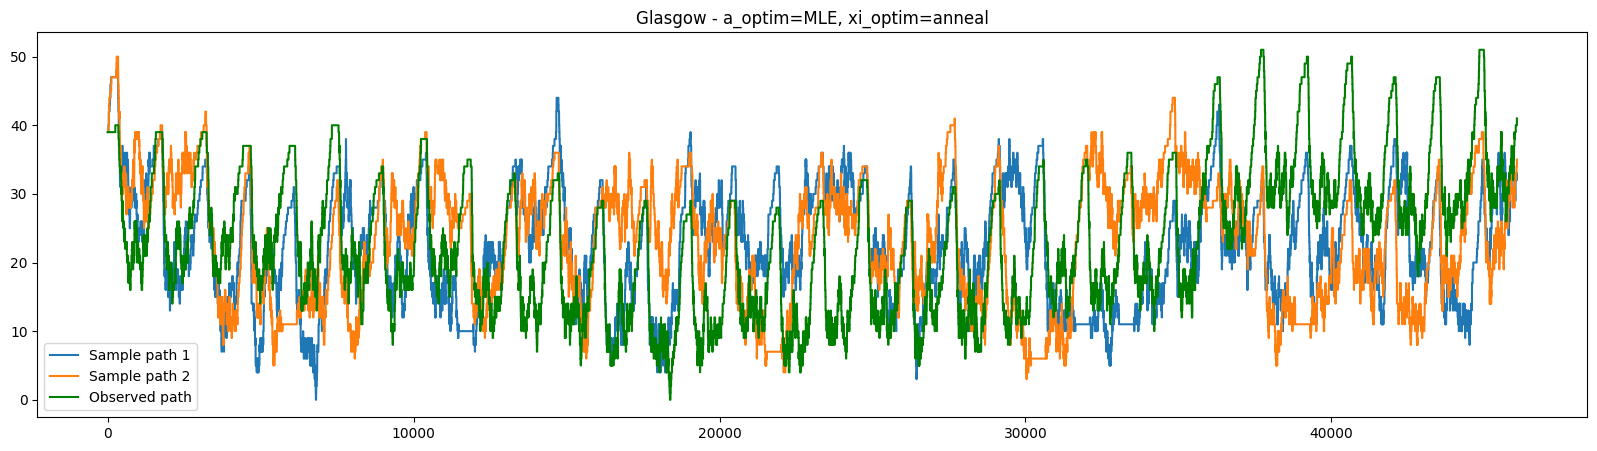

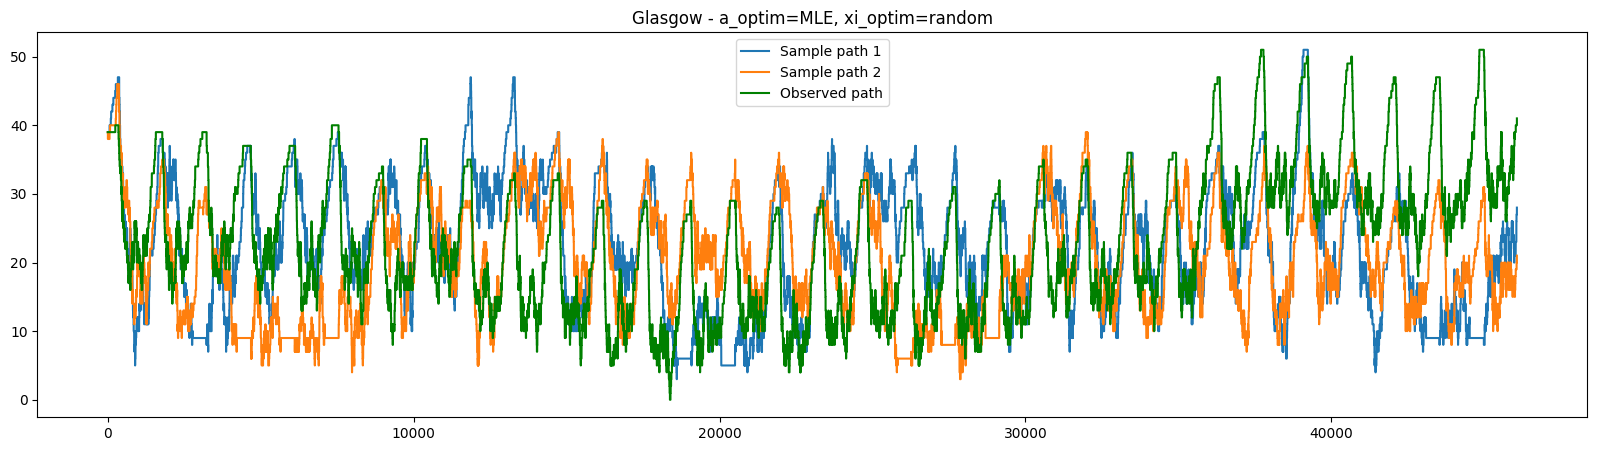

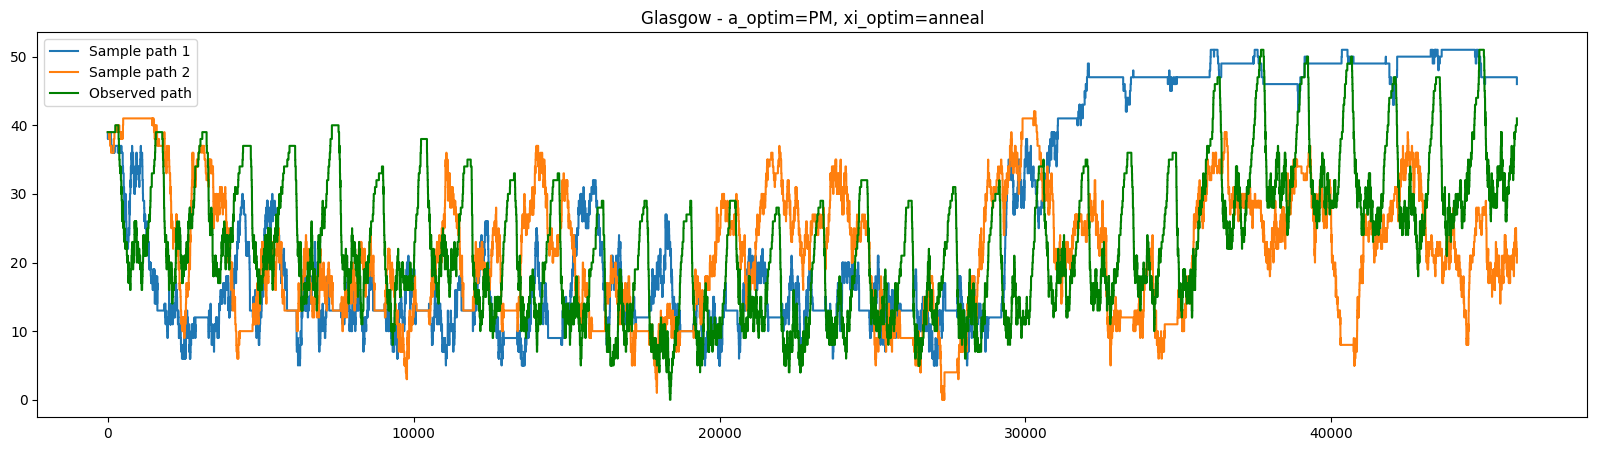

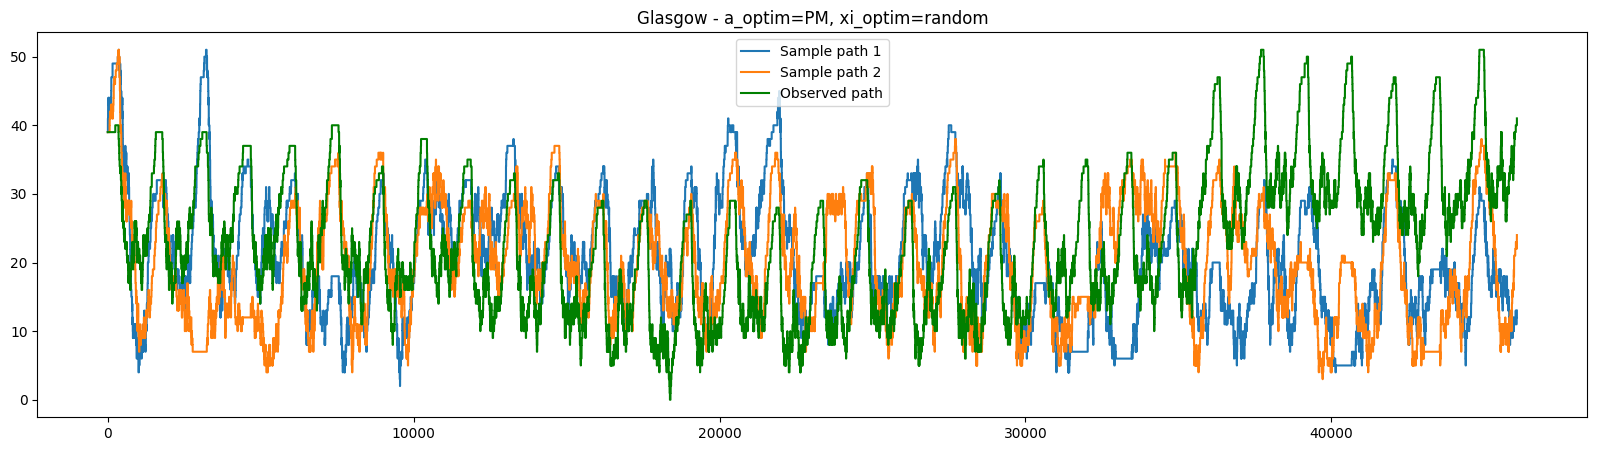

In [7]:
df = dfs['GLA']
states = df['State'].values
times = df['Minutes From Start'].values
S = max(states) + 1
#Default model structure - all 1 off diagonals have own parameter, all others 0
structure = np.zeros((S,S))
for i in range(S-1):
     structure[i,i+1] = 2*i + 1
     structure[i+1,i] = 2*i + 2

#Number of iterations for training xi
n_iter = 100

a_method = ['MLE', 'PM']
xi_method = ['anneal', 'random']

for a_m in a_method:
    for xi_m in xi_method:
        print(f'a_optim={a_m}, xi_optim={xi_m}')
        xi = [240,720,1200]
        mod = CTMC()
        err, log_l = mod.fit(states,times,xi,a_m,xi_m,N=n_iter, coeff_struct=structure)
        fig, axs = plt.subplots(figsize=(20,5))
        axs.set_title(f'Glasgow - a_optim={a_m}, xi_optim={xi_m}')
        for j in range(2):
            s,t = mod.generate_path(states[0],0,times[-1])
            axs.step(t,s,where='post', label=f'Sample path {j+1}')
        axs.step(times,states,where='post',color='green', label='Observed path')
        axs.legend()
        print(f'Chosen xi - {mod.xi}')
        print(f'log l= {log_l}')
        print(f'L1 error = {err[0]} +- {err[1]}')

Observations:

-

Experiment 3: Anomaly detection using the probability semi-group

Train models on an initial segment of the time series, then solve forwards equation to obtain the probability semi-group and use this to look for the number of planes exceeding expected range, i.e. where the probability of the observation is less than p = 0.05 and highlight this on a plot.

ABZ
Iteration 1: log l: -3878.9054770839393
Iteration 2: log l: -3878.9054770839393
Iteration 3: log l: -3934.742517706383
Iteration 4: log l: -3934.742517706383
Iteration 5: log l: -3937.3865054745274
Iteration 6: log l: -3937.3865054745274
Iteration 7: log l: -3937.3865054745274
Iteration 8: log l: -3937.3865054745274
Iteration 9: log l: -3943.4118111519606
Iteration 10: log l: -3928.9157122544134
Iteration 11: log l: -3928.9157122544134
Iteration 12: log l: -3814.7051293197474
Iteration 13: log l: -3832.2338749717433
Iteration 14: log l: -3768.001109496808
Iteration 15: log l: -3768.001109496808
Iteration 16: log l: -3768.001109496808
Iteration 17: log l: -3768.001109496808
Iteration 18: log l: -3768.001109496808
Iteration 19: log l: -3768.001109496808
Iteration 20: log l: -3893.9510753465615
Iteration 21: log l: -3893.9510753465615
Iteration 22: log l: -3893.9510753465615
Iteration 23: log l: -3893.9510753465615
Iteration 24: log l: -3893.9510753465615
Iteration 25: log l: -3893.95

C:\Users\thecd\Documents\Code\Markov_Chain\CTMC_Model.py:153: RuntimeWarning: invalid value encountered in divide
  a = np.divide(num,den)
C:\Users\thecd\Documents\Code\Markov_Chain\CTMC_Model.py:122: RuntimeWarning: divide by zero encountered in log
  term_1 = np.multiply(num,np.log(a1))


Iteration 11: log l: -358.7572291390901
Iteration 12: log l: -363.5543706529271
Iteration 13: log l: -363.5543706529271
Iteration 14: log l: -363.65730833493365
Iteration 15: log l: -359.35812351034343
Iteration 16: log l: -348.91633876229224
Iteration 17: log l: -361.96998768567653
Iteration 18: log l: -361.96998768567653
Iteration 19: log l: -361.96998768567653
Iteration 20: log l: -361.86705000367
Iteration 21: log l: -361.8522722718827
Iteration 22: log l: -362.1732512901457
Iteration 23: log l: -361.86705000367
Iteration 24: log l: -361.86705000367
Iteration 25: log l: -365.16333586095817
Iteration 26: log l: -365.16333586095817
Iteration 27: log l: -365.16333586095817
Iteration 28: log l: -365.14855812917085
Iteration 29: log l: -365.14855812917085
Iteration 30: log l: -363.8871744488349
Iteration 31: log l: -363.8871744488349
Iteration 32: log l: -354.06058923016735
Iteration 33: log l: -356.74258695976647
Iteration 34: log l: -351.74564047779927
Iteration 35: log l: -365.478435

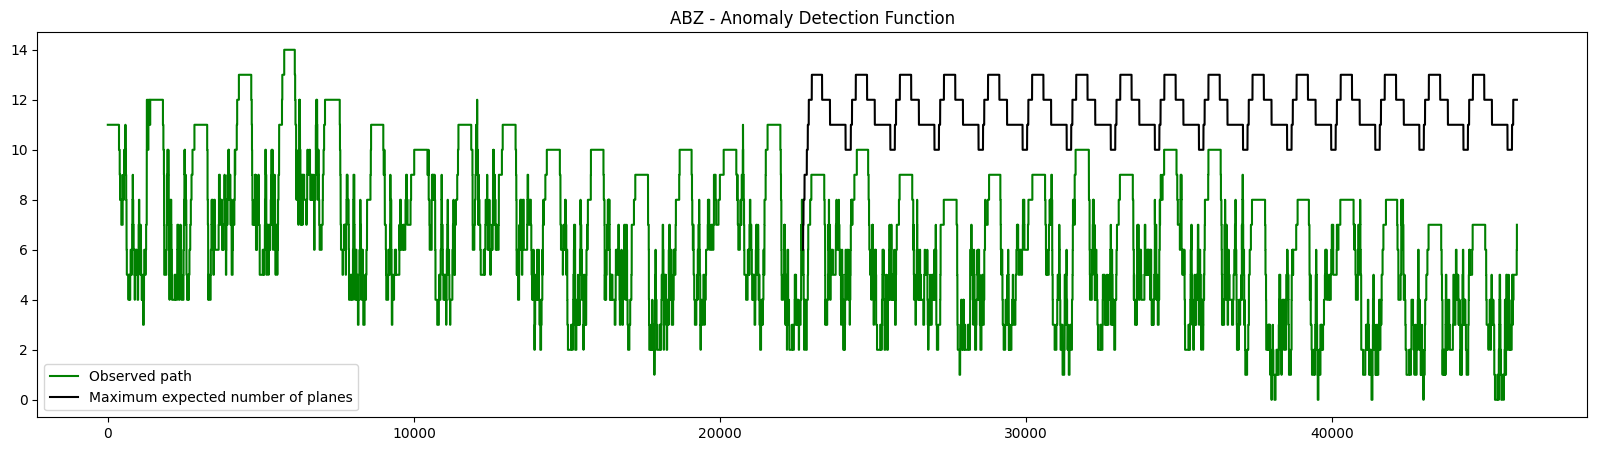

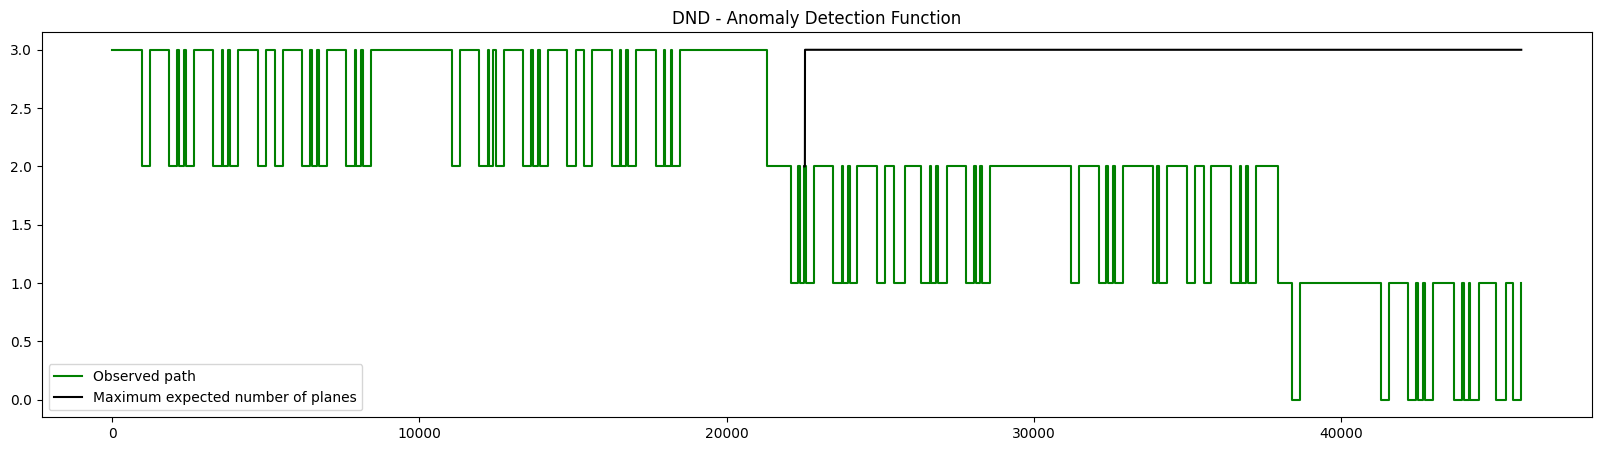

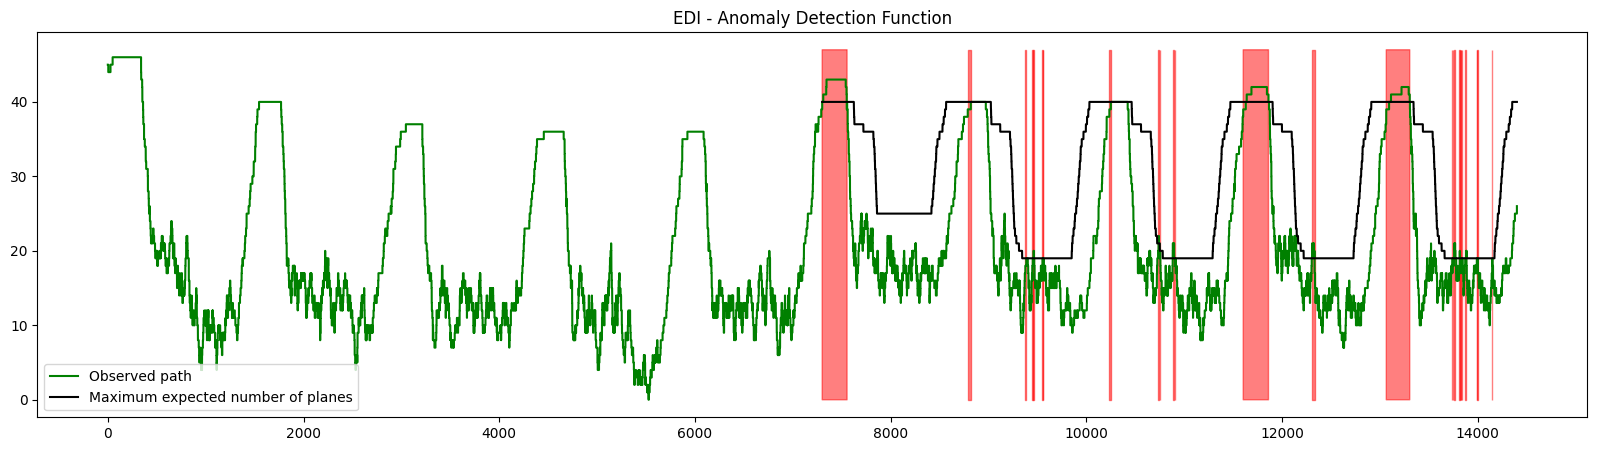

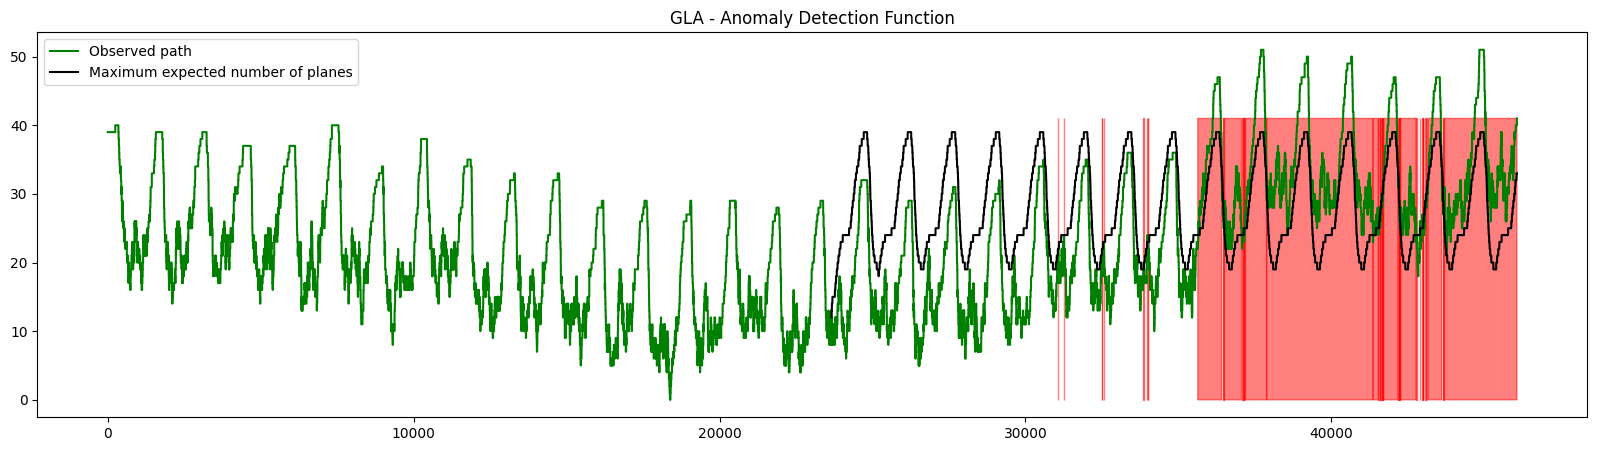

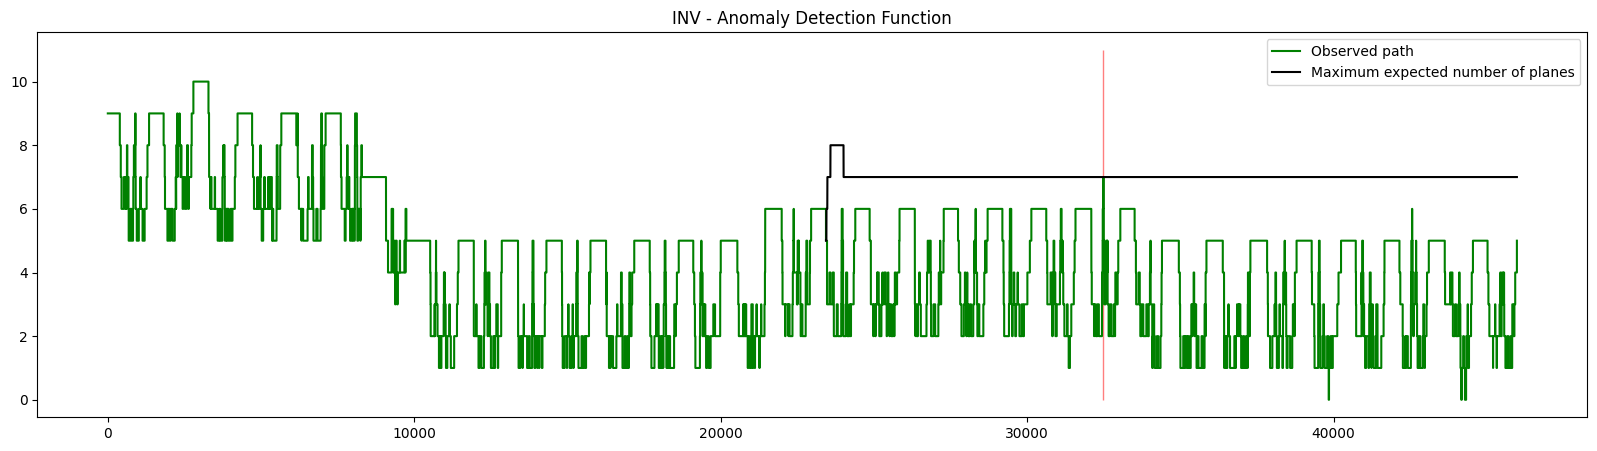

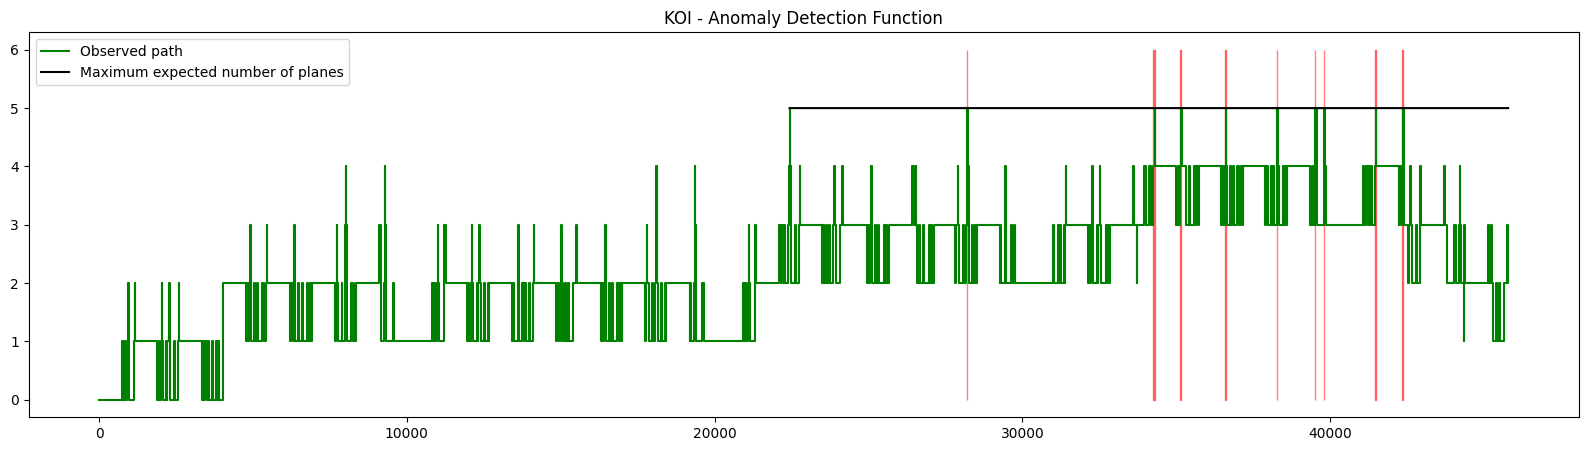

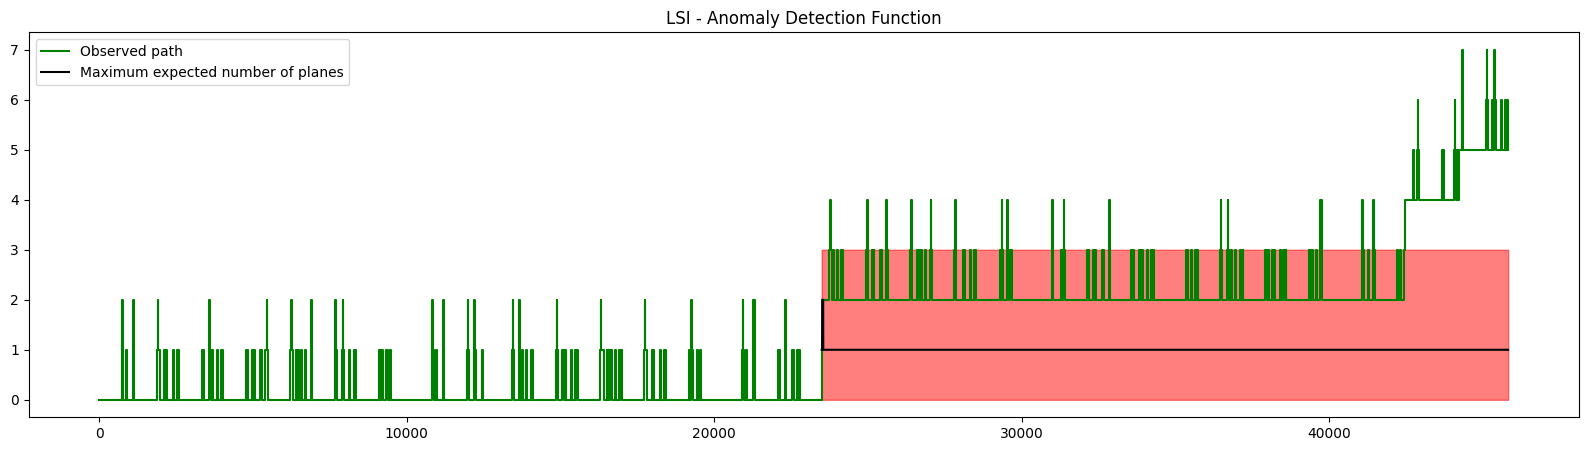

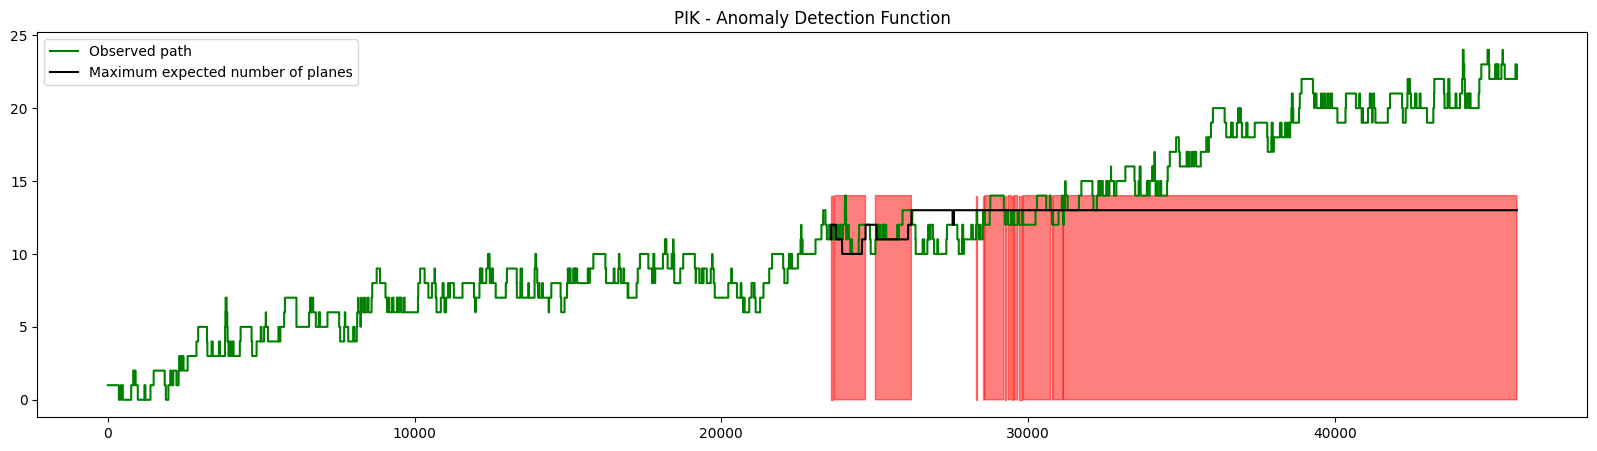

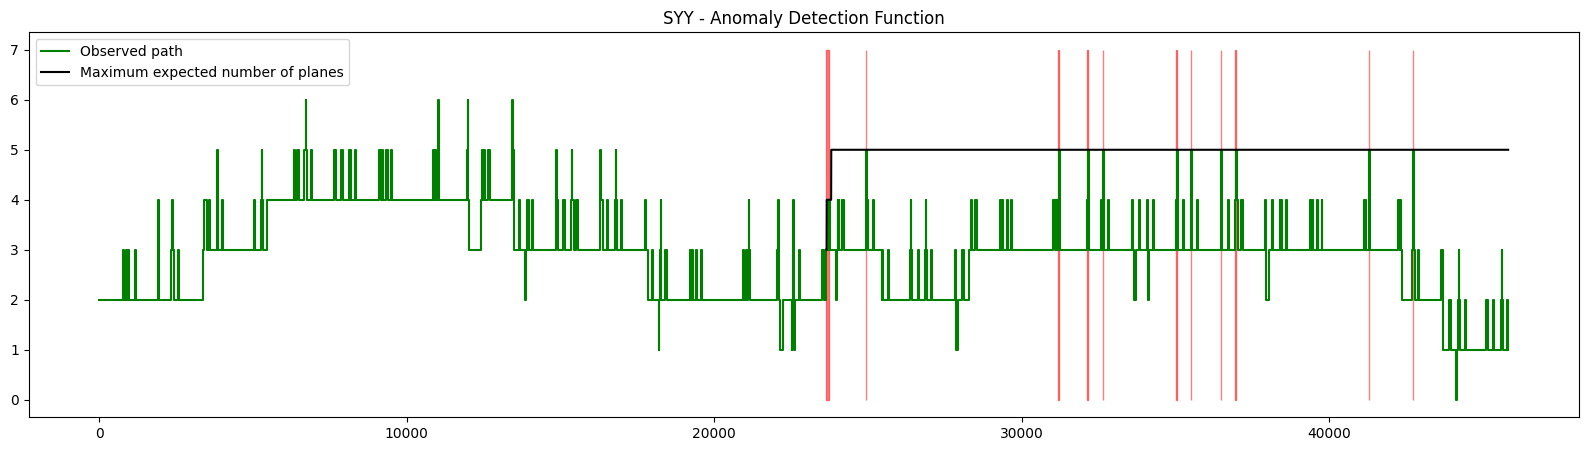

In [8]:
for c, df in dfs.items():
    print(c)
    n = len(df)
    #Creating training and observation data sets
    states_train = df['State'].head(int(n/2)).values
    states_obs = df['State'].tail(n - int(n/2)).values
    times_train = df['Minutes From Start'].head(int(n/2)).values
    times_obs = df['Minutes From Start'].tail(n - int(n/2)).values

    S = max(states_train) + 1
    #Default model structure - all 1 off diagonals have own parameter, all others 0
    structure = np.zeros((S,S))
    for i in range(S-1):
         structure[i,i+1] = 2*i + 1
         structure[i+1,i] = 2*i + 2

    #Number of iterations for training xi
    n_iter = 100
    xi = [240,720,1200]
    mod = CTMC()
    err, log_l = mod.fit(states_train,times_train,xi,'MLE','anneal',N=n_iter, coeff_struct=structure)

    #Initial probability distribution
    P_0 = np.zeros(S)
    P_0[states_train[-1]] = 1

    #Solve forwards equation
    eq_times, dist = mod.solve_forward_eq(times_train[-1], times_obs[-1], P_0)

    #Find smallest M(t) such that probability number of planes >= M is less than p
    p = 0.05
    dist_cdf = np.cumsum(dist,axis=0)
    M = np.argmax(dist_cdf > 1-p,axis=0)

    #Creating version of observed data adapted to eq_times for easier comparison
    fun = np.zeros_like(eq_times[:-1])
    for i in range(len(fun)):
        fun[i] = states_obs[bisect.bisect(times_obs,eq_times[i])]

    #Ploting full dataset and maximum expected state function
    fig, axs = plt.subplots(figsize=(20,5))
    axs.set_title(f'{c} - Anomaly Detection Function')
    axs.step(np.concatenate((times_train, times_obs)), np.concatenate((states_train, states_obs)), where='post',color='green', label='Observed path')
    axs.plot(eq_times,M, label='Maximum expected number of planes', color='black')
    axs.fill_between(eq_times[:-1],S,where=fun>=M[:-1],color='red', alpha=0.5)
    
    axs.legend()